# $\text{ARIMA}(p,d,q)$

ARIMA stands for Auto Regressive Integrated Moving Average. The intent of $\text{ARIMA}(p,d,q)$ is to construct a stationary, $\text{ARMA}(p,q)$ time series from a non-stationary time series by differencing $d$ times. Recall that an $\text{ARMA}(p,q)$ process is defined by,

$
\begin{align}
X_t = \varepsilon_t + \sum_{i=1}^p \varphi_i X_{t-i} + \sum_{i=1}^q \vartheta_i \varepsilon_{t-i}
\end{align}
\tag{1}
$

In terms of the lag operator $L X_t = X_{t-1}, L^2 X_t = X_{t-2}, L^3 X_t = X_{t-3}, \ldots$, The $\text{ARMA}(p,q)$ model can be written as,

$
\begin{align}
\left( 1 - \sum_{i=1}^p \varphi_i L^i \right) X_t = \left( 1  + \sum_{i=1}^q \vartheta_i L^i \right)\varepsilon_{t}
\end{align}
\tag{2}
$

The difference operator is given by $\Delta = (1 - L)$. If $X_t$ is stationary after $d$ differences it follows that $\left( 1 - L \right)^d X_t$ is stationary. This is the definition of integration order. Thus, $\text{ARIMA}(p,d,q)$ can be written as,

$
\begin{align}
\left( 1 - \sum_{i=1}^p \varphi_i L^i \right) \left( 1 - L \right)^d X_t = \left( 1  + \sum_{i=1}^q \vartheta_i L^i \right)\varepsilon_{t}
\end{align}
\tag{3}
$

The procedure followed to determine the order and coefficients of an $\text{ARIMA}(p,d,q)$ series is as follows.

1. Use ADF test to determine if series is stationary. To determine $d$ difference series until ADF test fails.
2. User PACF/ACF analysis to determine $p$ and $q$.
3. Perform regression on differenced series to determine coefficients.

## Includes

In [10]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import arima, stats, adf
from lib.plots import stack, comparison

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [11]:
nsample = 1000

def pacf_acf_plot(t, samples, nlags, σ, φ):
    title = f"AR(1) ACF-PACF σ={σ}, $\\varphi=${φ}"
    tacf, acf = stats.compute_acf(t, samples, nlags=nlags)
    tpacf, pacf = arima.compute_pacf(samples, nlags=nlags)
    comparison([acf, pacf], [tacf, tpacf], labels=["ACF", "PACF"], ylim=(-0.1, 1.0), title=title, figsize=(10, 6))

## $\text{ARIMA}(1,1,0)$ Example

In [12]:
nsample = 1000
σ = 1.0
nlags = 10

In [13]:
φ = [0.5]
d = 1
_, ar = arima.create_ar_source(φ=φ, npts=nsample)
t, arima_data = arima.create_arima_from_arma_source(arma=ar, d=d, npts=nsample)
tdiff_1, diff_1 = stats.compute_ndiff(t, arima_data, ndiff=1)

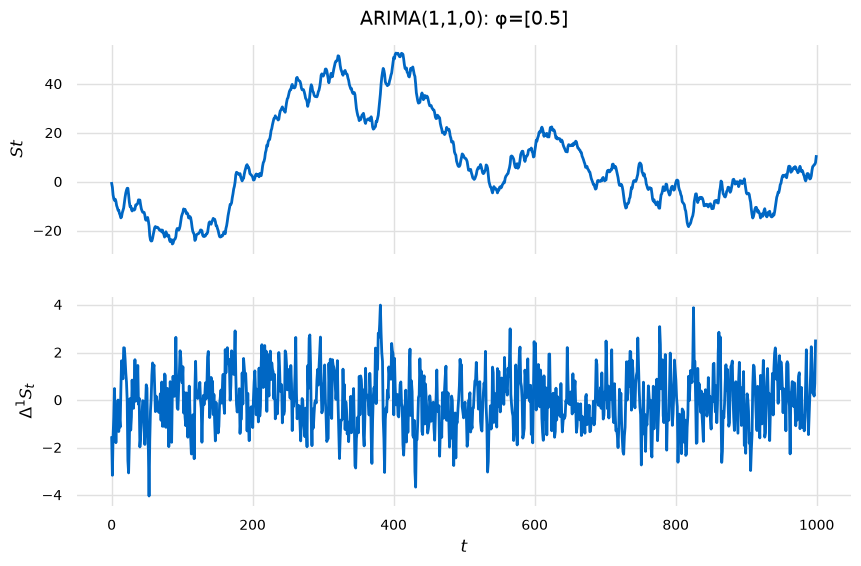

In [14]:
title=f"ARIMA(1,1,0): φ={φ}"
stack([arima_data, diff_1], title=title, xlabel=r"$t$", ylabels=[r"$St$", r"$\Delta^1 S_t$"])

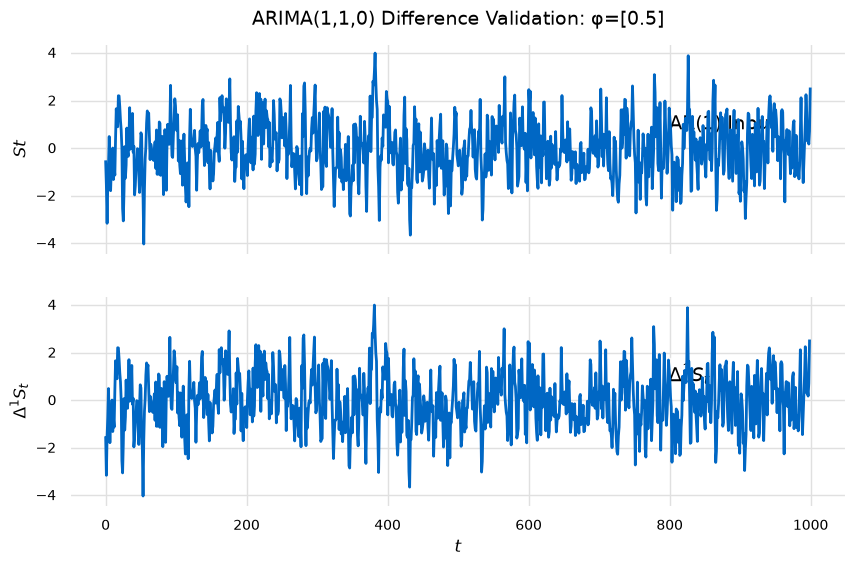

In [15]:
title = f"ARIMA(1,1,0) Difference Validation: φ={φ}"
stack([ar, diff_1], title=title, labels=[r"AR(1) Input", r"$\Delta^1 S_t$"], xlabel=r"$t$", ylabels=[r"$St$", r"$\Delta^1 S_t$"])

In [16]:
result, report = adf.compute_adf_test(arima_data)
result.summary()

╒════════════════╤════════════╕
│ Test Statistic │  -1.54153  │
├────────────────┼────────────┤
│ pvalue         │   0.115753 │
├────────────────┼────────────┤
│ Lags           │   1        │
├────────────────┼────────────┤
│ Number Obs     │ 998        │
╘════════════════╧════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56798 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Passed   │
╘════════════════╧══════════════════╧══════════╛


In [17]:
print(report.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "ea7e3662-eed6-498e-9c1e-2b9a2ed49f74",
                "label": "$t$",
                "value": -1.5415320594947743
            },
            "pval": {
                "test_id": "ea7e3662-eed6-498e-9c1e-2b9a2ed49f74",
                "label": "$p-value$",
                "value": 0.11575319598332617
            },
            "params": [],
            "sig": {
                "test_id": "ea7e3662-eed6-498e-9c1e-2b9a2ed49f74",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "ea7e3662-eed6-498e-9c1e-2b9a2ed49f74",
                "label": "$t_L$",
                "value": -2.5679839221127625
            },
            "upper": null,
            "test_id": "ea7e3662-eed6-498e-9c1e-2b9a2ed49f74"
        },
    

In [18]:
result, report = adf.compute_adf_test(diff_1)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -17.3458      │
├────────────────┼───────────────┤
│ pvalue         │   9.92186e-29 │
├────────────────┼───────────────┤
│ Lags           │   0           │
├────────────────┼───────────────┤
│ Number Obs     │ 998           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56798 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [19]:
print(report.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "9cdae0aa-0f83-49a9-a2da-4403579f2ba8",
                "label": "$t$",
                "value": -17.345769533295343
            },
            "pval": {
                "test_id": "9cdae0aa-0f83-49a9-a2da-4403579f2ba8",
                "label": "$p-value$",
                "value": 9.92186192085094e-29
            },
            "params": [],
            "sig": {
                "test_id": "9cdae0aa-0f83-49a9-a2da-4403579f2ba8",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "9cdae0aa-0f83-49a9-a2da-4403579f2ba8",
                "label": "$t_L$",
                "value": -2.5679839221127625
            },
            "upper": null,
            "test_id": "9cdae0aa-0f83-49a9-a2da-4403579f2ba8"
        },
   

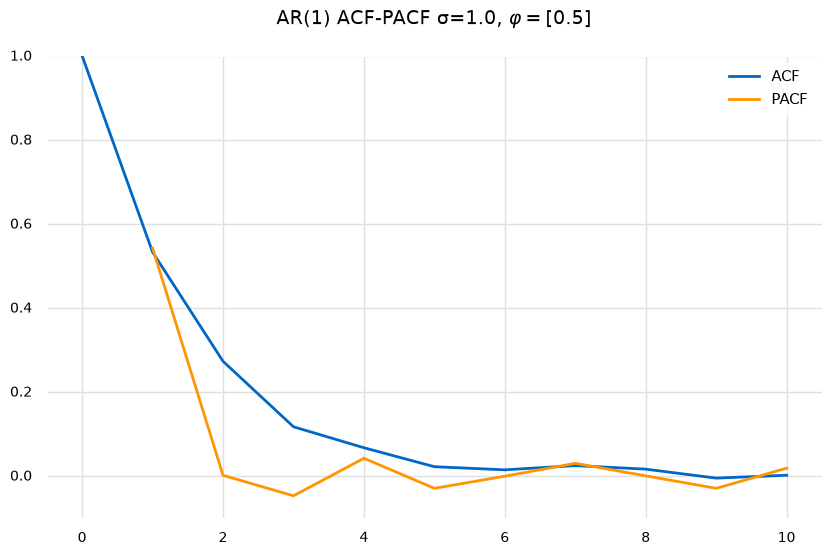

In [20]:
pacf_acf_plot(t, diff_1, nlags, σ, φ)

In [21]:
result, result_model = arima.compute_ar_estimate(diff_1, order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1418.798
Date:                Sun, 23 Aug 2026   AIC                           2843.596
Time:                        13:40:52   BIC                           2858.316
Sample:                             0   HQIC                          2849.191
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0120      0.068      0.177      0.860      -0.121       0.145
ar.L1          0.5354      0.028     19.428      0.000       0.481       0.589
sigma2         1.0022      0.048     21.007      0.000       0.909       1.096
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):                 2.21
Prob(Q):                              0.81   Prob(JB):                         0.33
Heteroskedasticity (H):               1.08   Skew:                             0.03
Prob(H) (two-sided):                  0.50   Kurtosis:                         2.78
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [22]:
print(report.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "9cdae0aa-0f83-49a9-a2da-4403579f2ba8",
                "label": "$t$",
                "value": -17.345769533295343
            },
            "pval": {
                "test_id": "9cdae0aa-0f83-49a9-a2da-4403579f2ba8",
                "label": "$p-value$",
                "value": 9.92186192085094e-29
            },
            "params": [],
            "sig": {
                "test_id": "9cdae0aa-0f83-49a9-a2da-4403579f2ba8",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "9cdae0aa-0f83-49a9-a2da-4403579f2ba8",
                "label": "$t_L$",
                "value": -2.5679839221127625
            },
            "upper": null,
            "test_id": "9cdae0aa-0f83-49a9-a2da-4403579f2ba8"
        },
   

## $\text{ARIMA}(1,2,0)$ Example

In [23]:
φ = [0.75]
d = 2
_, ar = arima.create_ar_source(φ=φ, npts=nsample)
t, arima_data = arima.create_arima_from_arma_source(arma=ar, d=d, npts=nsample)
tdiff_1, diff_1 = stats.compute_ndiff(t, arima_data, ndiff=1)
tdiff_2, diff_2 = stats.compute_ndiff(t, arima_data, ndiff=2)

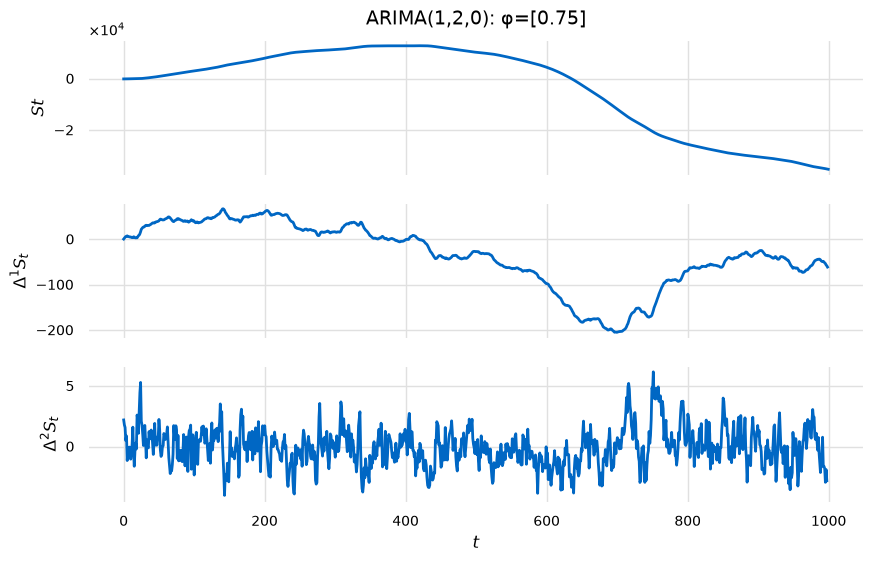

In [24]:
title = f"ARIMA(1,2,0): φ={φ}"
stack([arima_data, diff_1, diff_2], title=title, xlabel=r"$t$", ylabels=[r"$St$", r"$\Delta^1 S_t$", r"$\Delta^2 S_t$"])

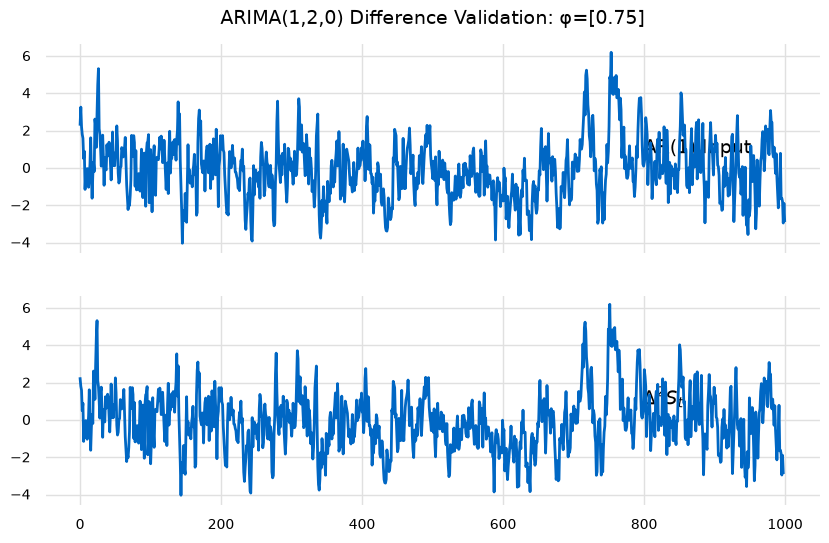

In [25]:
title = f"ARIMA(1,2,0) Difference Validation: φ={φ}"
stack([ar, diff_2], title=title, labels=[r"AR(1) Input", r"$\Delta^2 S_t$"])

In [26]:
result, report = adf.compute_adf_test(arima_data)
result.summary()

╒════════════════╤═════════════╕
│ Test Statistic │  -1.69209   │
├────────────────┼─────────────┤
│ pvalue         │   0.0858092 │
├────────────────┼─────────────┤
│ Lags           │   2         │
├────────────────┼─────────────┤
│ Number Obs     │ 997         │
╘════════════════╧═════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [27]:
print(report.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "c1a7d968-1e9a-4b3a-b21b-61a07044d4cc",
                "label": "$t$",
                "value": -1.692085131624841
            },
            "pval": {
                "test_id": "c1a7d968-1e9a-4b3a-b21b-61a07044d4cc",
                "label": "$p-value$",
                "value": 0.0858092071963053
            },
            "params": [],
            "sig": {
                "test_id": "c1a7d968-1e9a-4b3a-b21b-61a07044d4cc",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "c1a7d968-1e9a-4b3a-b21b-61a07044d4cc",
                "label": "$t_L$",
                "value": -2.5679861764430703
            },
            "upper": null,
            "test_id": "c1a7d968-1e9a-4b3a-b21b-61a07044d4cc"
        },
      

In [28]:
result, report = adf.compute_adf_test(diff_1)
result.summary()

╒════════════════╤════════════╕
│ Test Statistic │  -0.611209 │
├────────────────┼────────────┤
│ pvalue         │   0.449935 │
├────────────────┼────────────┤
│ Lags           │   1        │
├────────────────┼────────────┤
│ Number Obs     │ 997        │
╘════════════════╧════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Passed   │
╘════════════════╧══════════════════╧══════════╛


In [29]:
print(report.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "58d9ad9a-90d3-40a6-9d45-ef78e5b5cc3f",
                "label": "$t$",
                "value": -0.6112087579481906
            },
            "pval": {
                "test_id": "58d9ad9a-90d3-40a6-9d45-ef78e5b5cc3f",
                "label": "$p-value$",
                "value": 0.4499351343283471
            },
            "params": [],
            "sig": {
                "test_id": "58d9ad9a-90d3-40a6-9d45-ef78e5b5cc3f",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "58d9ad9a-90d3-40a6-9d45-ef78e5b5cc3f",
                "label": "$t_L$",
                "value": -2.5679861764430703
            },
            "upper": null,
            "test_id": "58d9ad9a-90d3-40a6-9d45-ef78e5b5cc3f"
        },
     

In [30]:
result, report = adf.compute_adf_test(diff_2)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -11.7621      │
├────────────────┼───────────────┤
│ pvalue         │   2.07015e-21 │
├────────────────┼───────────────┤
│ Lags           │   0           │
├────────────────┼───────────────┤
│ Number Obs     │ 997           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [31]:
print(report.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "bf28cff1-3798-442b-be47-2e03b26742e1",
                "label": "$t$",
                "value": -11.762086382997621
            },
            "pval": {
                "test_id": "bf28cff1-3798-442b-be47-2e03b26742e1",
                "label": "$p-value$",
                "value": 2.070146214092519e-21
            },
            "params": [],
            "sig": {
                "test_id": "bf28cff1-3798-442b-be47-2e03b26742e1",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "bf28cff1-3798-442b-be47-2e03b26742e1",
                "label": "$t_L$",
                "value": -2.5679861764430703
            },
            "upper": null,
            "test_id": "bf28cff1-3798-442b-be47-2e03b26742e1"
        },
  

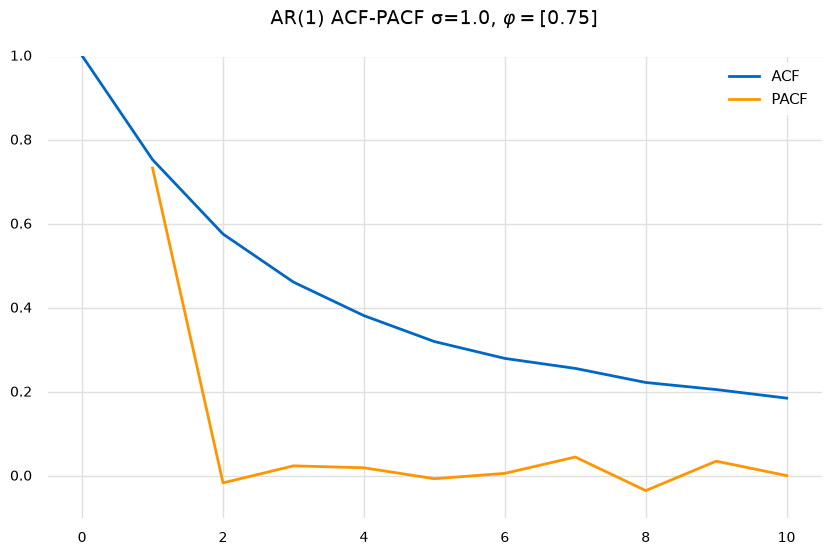

In [32]:
pacf_acf_plot(t, diff_2, nlags, σ, φ)

In [33]:
result, result_model = arima.compute_ar_estimate(diff_2, order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  998
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1445.364
Date:                Sun, 23 Aug 2026   AIC                           2896.728
Time:                        13:40:53   BIC                           2911.446
Sample:                             0   HQIC                          2902.322
                                - 998                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0632      0.133     -0.474      0.636      -0.325       0.198
ar.L1          0.7558      0.019     39.203      0.000       0.718       0.794
sigma2         1.0595      0.049     21.572      0.000       0.963       1.156
===================================================================================
Ljung-Box (L1) (Q):                   0.27   Jarque-Bera (JB):                 1.41
Prob(Q):                              0.60   Prob(JB):                         0.49
Heteroskedasticity (H):               1.04   Skew:                             0.07
Prob(H) (two-sided):                  0.75   Kurtosis:                         2.87
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## $\text{ARIMA}(2,2,0)$ Example

In [34]:
φ = [0.25, 0.4]
d = 2
_, ar = arima.create_ar_source(φ=φ, npts=nsample)
t, arima_data = arima.create_arima_from_arma_source(arma=ar, d=d, npts=nsample)
tdiff_1, diff_1 = stats.compute_ndiff(t, arima_data, ndiff=1)
tdiff_2, diff_2 = stats.compute_ndiff(t, arima_data, ndiff=2)

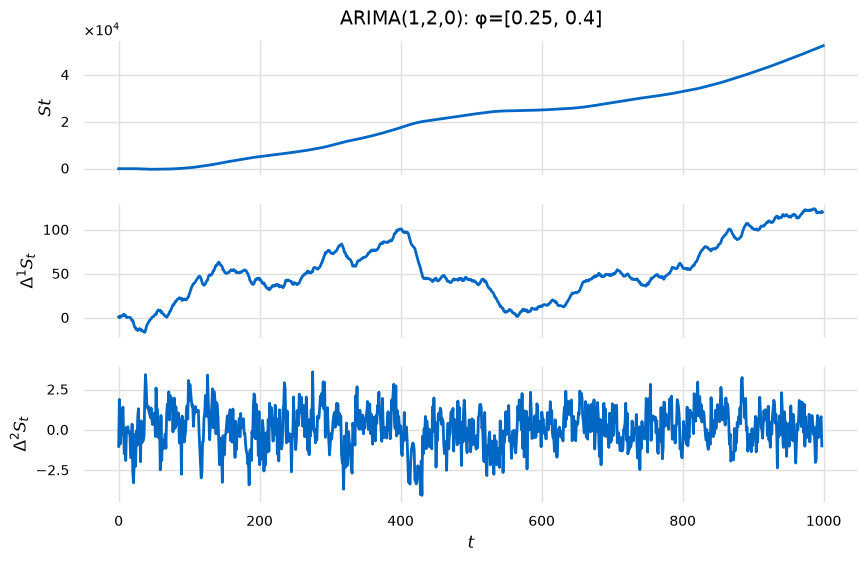

In [35]:
title = f"ARIMA(1,2,0): φ={φ}"
stack([arima_data, diff_1, diff_2], title=title, xlabel=r"$t$", ylabels=[r"$St$", r"$\Delta^1 S_t$", r"$\Delta^2 S_t$"])

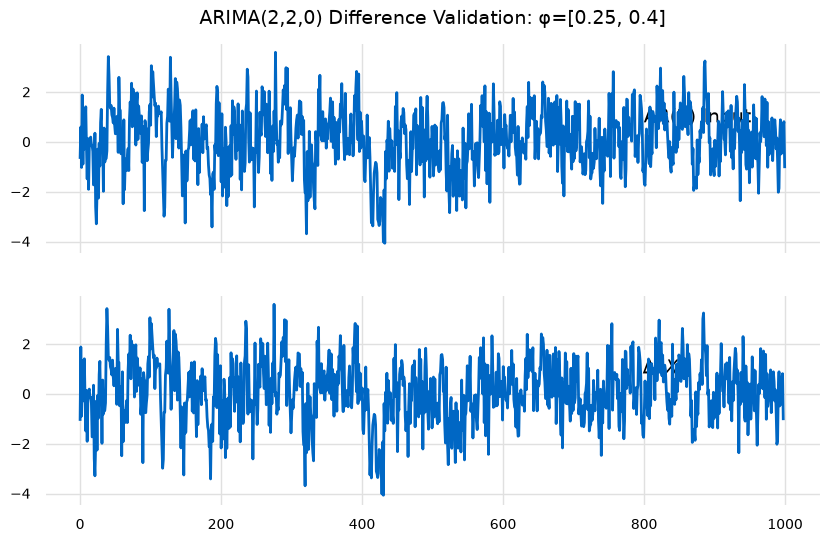

In [36]:
title = f"ARIMA(2,2,0) Difference Validation: φ={φ}"
stack([ar, diff_2], title=title, labels=[r"AR(2) Input", r"$\Delta^2 X_t$"])

In [37]:
result, report = adf.compute_adf_test(arima_data)
result.summary()

╒════════════════╤═══════════╕
│ Test Statistic │   1.22383 │
├────────────────┼───────────┤
│ pvalue         │   0.943   │
├────────────────┼───────────┤
│ Lags           │   3       │
├────────────────┼───────────┤
│ Number Obs     │ 996       │
╘════════════════╧═══════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Passed   │
╘════════════════╧══════════════════╧══════════╛


In [38]:
print(report.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "1c0ddaa5-8741-428f-be76-9eb1ebc9f69f",
                "label": "$t$",
                "value": 1.223832182192117
            },
            "pval": {
                "test_id": "1c0ddaa5-8741-428f-be76-9eb1ebc9f69f",
                "label": "$p-value$",
                "value": 0.9429995063744311
            },
            "params": [],
            "sig": {
                "test_id": "1c0ddaa5-8741-428f-be76-9eb1ebc9f69f",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "1c0ddaa5-8741-428f-be76-9eb1ebc9f69f",
                "label": "$t_L$",
                "value": -2.567988435307495
            },
            "upper": null,
            "test_id": "1c0ddaa5-8741-428f-be76-9eb1ebc9f69f"
        },
        

In [39]:
result, report = adf.compute_adf_test(diff_1)
result.summary()

╒════════════════╤════════════╕
│ Test Statistic │   0.479928 │
├────────────────┼────────────┤
│ pvalue         │   0.82023  │
├────────────────┼────────────┤
│ Lags           │   2        │
├────────────────┼────────────┤
│ Number Obs     │ 996        │
╘════════════════╧════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Passed   │
╘════════════════╧══════════════════╧══════════╛


In [40]:
print(report.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "bac29508-44d0-462d-9a39-0e1cf21a7d5d",
                "label": "$t$",
                "value": 0.4799281346625563
            },
            "pval": {
                "test_id": "bac29508-44d0-462d-9a39-0e1cf21a7d5d",
                "label": "$p-value$",
                "value": 0.8202296659587429
            },
            "params": [],
            "sig": {
                "test_id": "bac29508-44d0-462d-9a39-0e1cf21a7d5d",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "bac29508-44d0-462d-9a39-0e1cf21a7d5d",
                "label": "$t_L$",
                "value": -2.567988435307495
            },
            "upper": null,
            "test_id": "bac29508-44d0-462d-9a39-0e1cf21a7d5d"
        },
       

In [41]:
result, report = adf.compute_adf_test(diff_2)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -11.2823      │
├────────────────┼───────────────┤
│ pvalue         │   1.88581e-20 │
├────────────────┼───────────────┤
│ Lags           │   1           │
├────────────────┼───────────────┤
│ Number Obs     │ 996           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [42]:
print(report.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "063596d0-71dc-473a-9faa-6752b851e7d2",
                "label": "$t$",
                "value": -11.282250391908182
            },
            "pval": {
                "test_id": "063596d0-71dc-473a-9faa-6752b851e7d2",
                "label": "$p-value$",
                "value": 1.8858070327832108e-20
            },
            "params": [],
            "sig": {
                "test_id": "063596d0-71dc-473a-9faa-6752b851e7d2",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "063596d0-71dc-473a-9faa-6752b851e7d2",
                "label": "$t_L$",
                "value": -2.567988435307495
            },
            "upper": null,
            "test_id": "063596d0-71dc-473a-9faa-6752b851e7d2"
        },
  

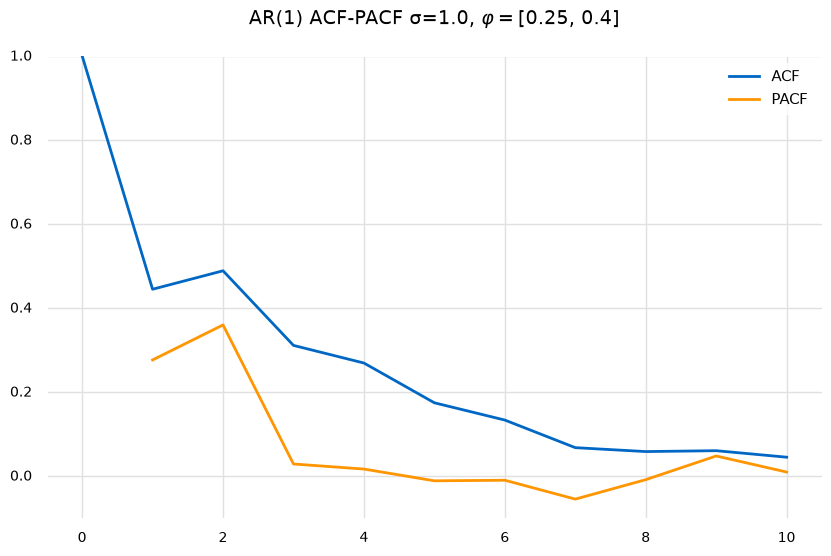

In [43]:
pacf_acf_plot(t, diff_2, nlags, σ, φ)

In [44]:
result, result_model = arima.compute_ar_estimate(diff_2, order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  998
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1445.703
Date:                Sun, 23 Aug 2026   AIC                           2899.406
Time:                        13:40:53   BIC                           2919.029
Sample:                             0   HQIC                          2906.865
                                - 998                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1177      0.092      1.281      0.200      -0.062       0.298
ar.L1          0.2821      0.029      9.655      0.000       0.225       0.339
ar.L2          0.3629      0.030     12.194      0.000       0.305       0.421
sigma2         1.0606      0.050     21.087      0.000       0.962       1.159
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 2.36
Prob(Q):                              0.89   Prob(JB):                         0.31
Heteroskedasticity (H):               0.77   Skew:                            -0.06
Prob(H) (two-sided):                  0.02   Kurtosis:                         2.80
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""